<a href="https://colab.research.google.com/github/drtommyhudson77-ai/gdp-dashboard/blob/main/RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Simple toy dataset
X = [
    [2, 1],
    [3, 1],
    [4, 2],
    [5, 2],
    [6, 3],
    [7, 3]
]

# Binary labels
y = [0, 0, 0, 1, 1, 1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,     # number of trees
    max_depth=3,          # limit tree depth
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)



In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)


1.0


<Axes: xlabel='class', ylabel='survived'>

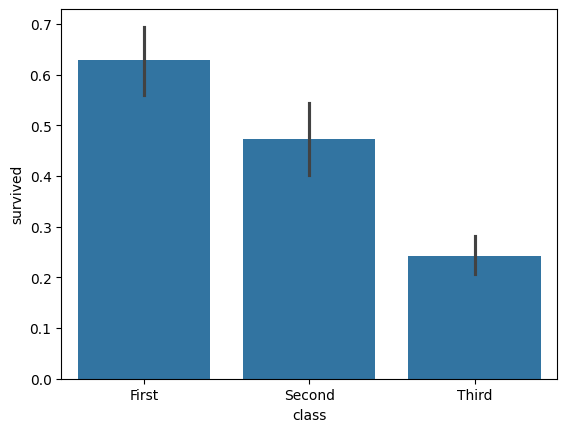

In [ ]:
import seaborn as sns
import pandas as pd

# Load dataset
df = sns.load_dataset("titanic")
df.sort_values(by=['fare','age'], ascending=[False, False],inplace=True)
df.head(10)

sns.barplot(df, x='class', y='survived')

<Axes: xlabel='sex', ylabel='age'>

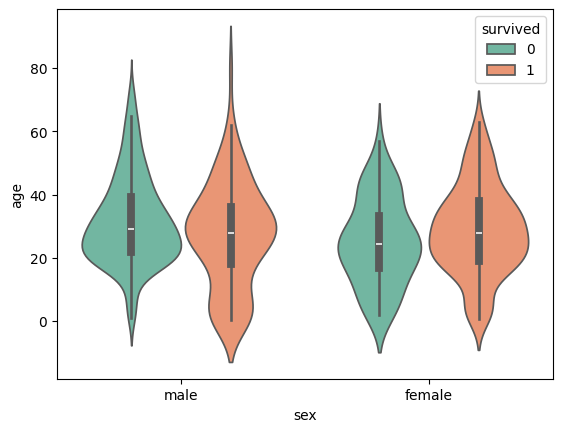

In [ ]:
import seaborn as sns
sns.violinplot( x='sex', y='age', hue='survived', split=False, data=df, palette='Set2')

<Axes: xlabel='sex', ylabel='age'>

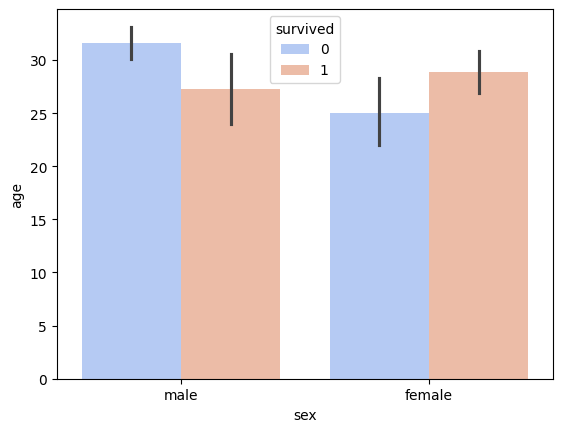

In [ ]:
import seaborn as sns
sns.barplot( x='sex', y='age', hue='survived', data=df, palette='coolwarm')

In [ ]:
features = [
    "pclass",     # passenger class
    "sex",
    "age",
    "sibsp",      # siblings/spouses aboard
    "parch",      # parents/children aboard
    "fare",
    "embarked"
]

target = "survived"

df = df[features + [target]]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
numeric_features = ["age", "fare", "sibsp", "parch", "pclass"]
categorical_features = ["sex", "embarked"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    random_state=42
)

clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", model),
    ]
)

clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'fare', 'sibsp',
                                                   'parch', 'pclass']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=4, min_samples_leaf=10,
                                        random_state=42))])

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7932960893854749
              precision    recall  f1-score   support

           0       0.77      0.91      0.84       105
           1       0.84      0.62      0.71        74

    accuracy                           0.79       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.80      0.79      0.79       179



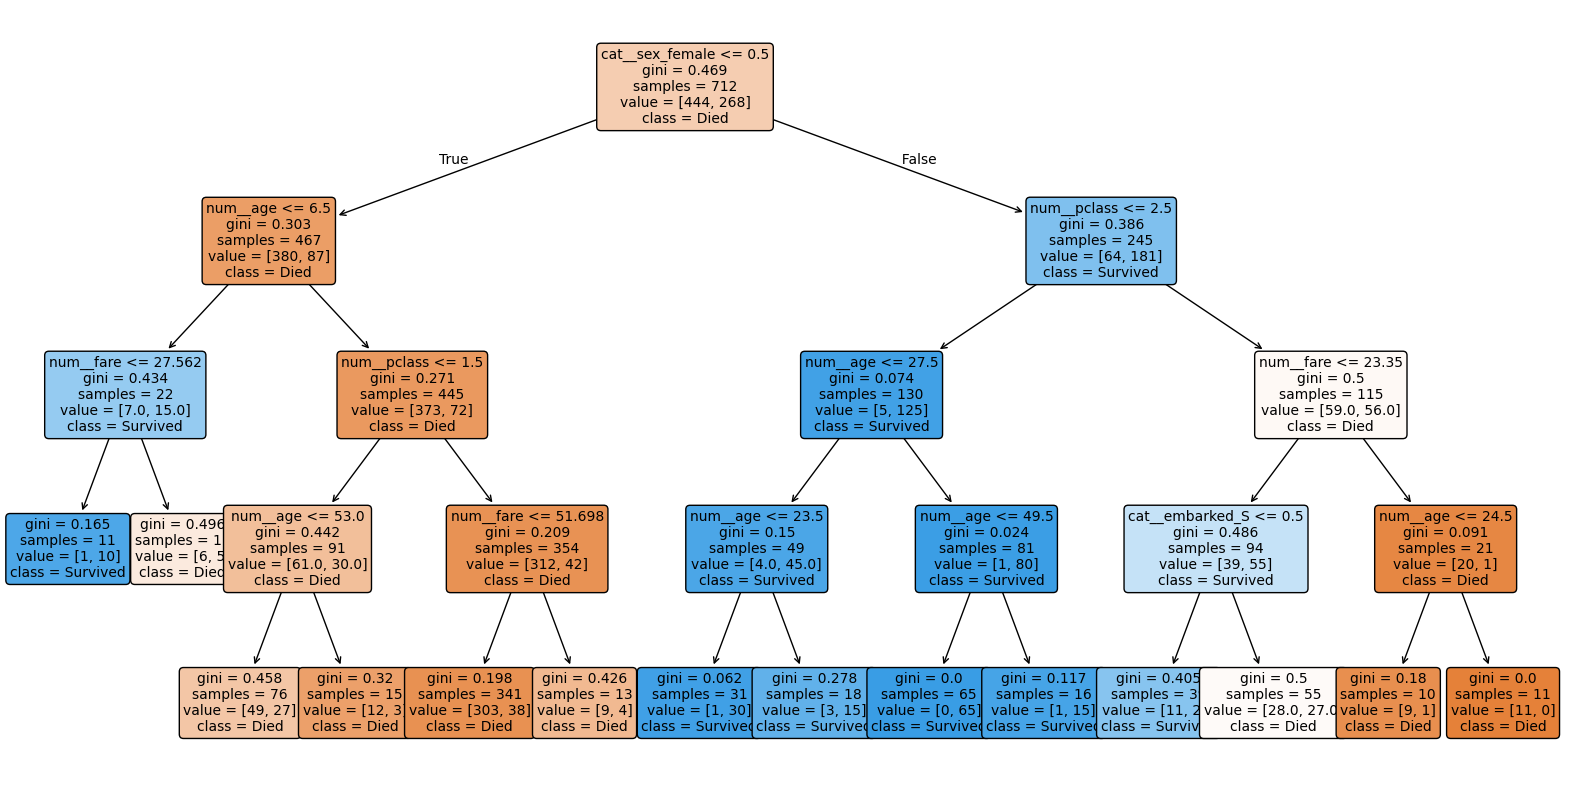

In [ ]:
# Extract trained tree


from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree = clf.named_steps["classifier"]
feature_names = clf.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=["Died", "Survived"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

Accuracy: 0.8156424581005587

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.83      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179


Top 10 Most Important Features:

           feature  importance
6    cat__sex_male    0.258065
5  cat__sex_female    0.243978
1        num__fare    0.156971
4      num__pclass    0.123029
0         num__age    0.114214
2       num__sibsp    0.041841
3       num__parch    0.027041
9  cat__embarked_S    0.016436
7  cat__embarked_C    0.012872
8  cat__embarked_Q    0.005553


<BarContainer object of 10 artists>

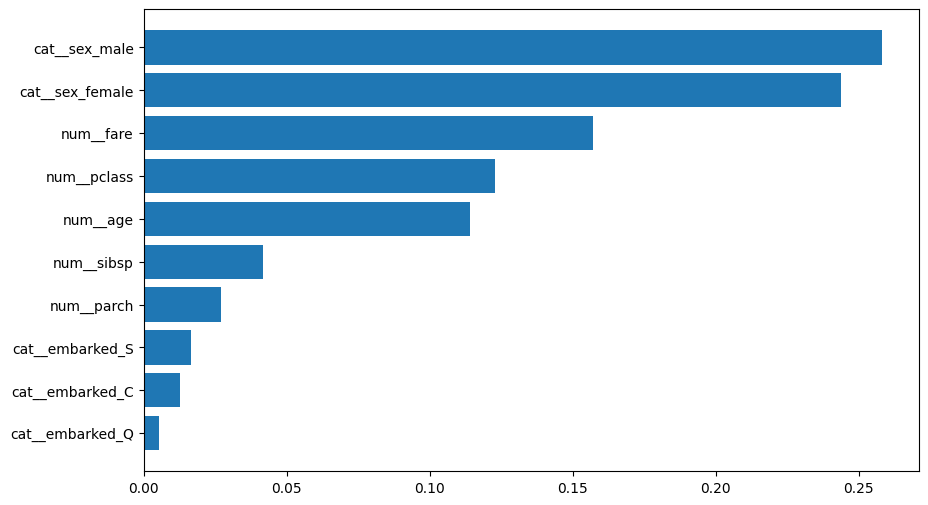

In [ ]:
# ==============================
# Random Forest on Titanic Data
# ==============================

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ------------------------------
# 1. Load dataset
# ------------------------------
df = sns.load_dataset("titanic")

# ------------------------------
# 2. Select features and target
# ------------------------------
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

target = "survived"

df = df[features + [target]]

X = df.drop(columns=target)
y = df[target]

# ------------------------------
# 3. Train / test split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------
# 4. Preprocessing
# ------------------------------
numeric_features = ["age", "fare", "sibsp", "parch", "pclass"]
categorical_features = ["sex", "embarked"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# ------------------------------
# 5. Random Forest model
# ------------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf)
    ]
)

# ------------------------------
# 6. Train model
# ------------------------------
model.fit(X_train, y_train)

# ------------------------------
# 7. Evaluate model
# ------------------------------
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ------------------------------
# 8. Feature importance
# ------------------------------
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = model.named_steps["classifier"].feature_importances_

feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

print("\nTop 10 Most Important Features:\n")
print(feature_importance.head(10))

# ------------------------------
# 9. Plot feature importance
# ------------------------------
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance["feature"][:10][::-1],
    feature_importance["importance"][:10][::-1]
)


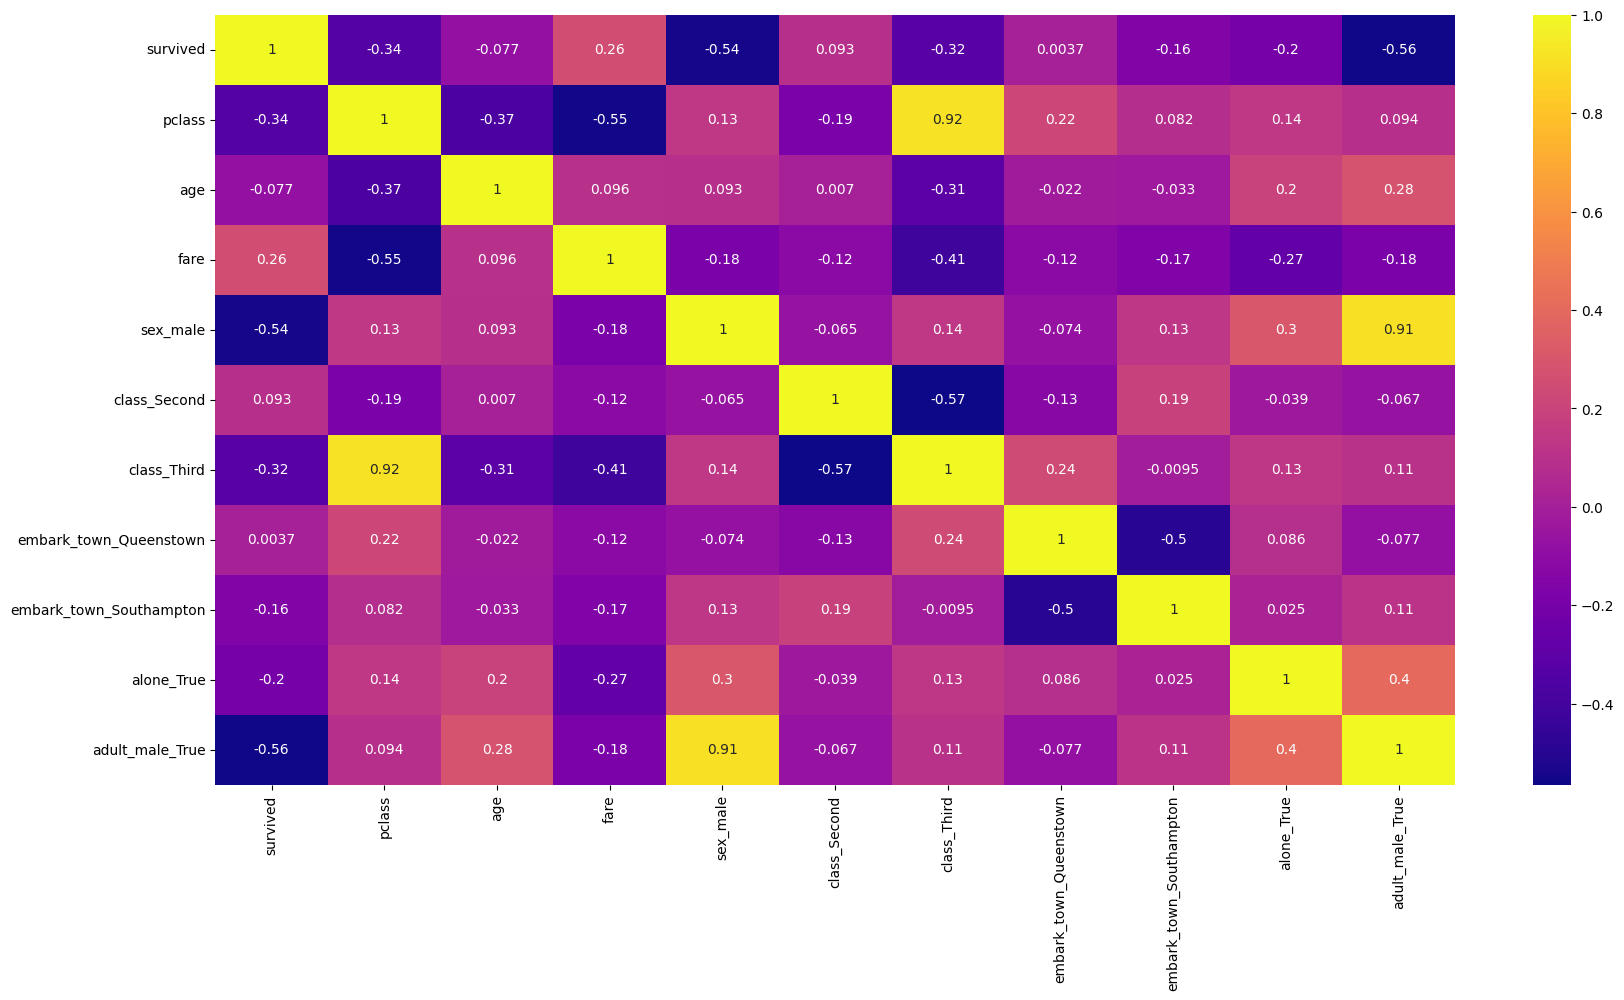

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))


titanic = sns.load_dataset("titanic")

df = pd.DataFrame(titanic)

del df ['parch']
del df ['sibsp']
del df ['deck']
del df ['alive']
del df ['who']
del df ['embarked']


df = pd.get_dummies(df, columns=['sex', 'class','embark_town', 'alone', 'adult_male'], drop_first=True)

df.head()

df.corr()

sns.heatmap(df.corr(), annot=True, cmap='plasma')

plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import plotly.express as px

# Load data
titanic = sns.load_dataset("titanic")
df = pd.DataFrame(titanic)

# Drop unwanted columns
del df['parch']
del df['sibsp']
del df['deck']
del df['alive']
del df['who']
del df['embarked']

# Create dummy variables
df = pd.get_dummies(
    df,
    columns=['sex', 'class', 'embark_town', 'alone', 'adult_male'],
    drop_first=True
)

# Compute correlation matrix
corr = df.corr()

# --------------------
# Plotly heatmap
# --------------------
fig = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale="Plasma",
    width=1000,    # change width here
    height=750,   # change height here
    title="Correlation Heatmap (Titanic Dataset)"
)

fig.update_layout(
    xaxis_title="Features",
    yaxis_title="Features"
)

fig.show()